# Fase 1: modelo predictivo de la calificación de películas

Proyecto integrador de Modelos y Simulación de Sistemas I (Universidad de Antioquia).
Equipo: Alejandro Múnera Ramírez, Miguel Ángel Altamiranda y Juan Esteban González Duque.

**Objetivo.** Construir un modelo de regresión que prediga `vote_average` (calificación promedio de los usuarios de TMDB, escala 0 a 10) usando solo características que se conocen antes o al momento del estreno de una película.

**Dataset.** The Movies Dataset (Rounak Banik, Kaggle), archivo `movies_metadata.csv`. El README del repositorio explica cómo descargarlo y dónde ubicarlo (`data/movies_metadata.csv`).

**Estructura del notebook.**

1. Carga de datos
2. Limpieza: filas corruptas y películas duplicadas
3. Análisis exploratorio (EDA)
4. Preparación de variables y fuga de información
5. División train/test y Pipeline de preprocesamiento
6. Modelos y evaluación
7. Guardado del modelo

El notebook está pensado para ejecutarse de principio a fin (Restart & Run All) con el kernel del entorno virtual del proyecto.

## 1. Carga de datos

In [1]:
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Semilla única para todo lo aleatorio del notebook (reproducibilidad)
SEMILLA = 42

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

# Estilo de gráficos: un solo color para una sola serie, rejilla discreta
COLOR_PRINCIPAL = "#2a78d6"
plt.rcParams.update({
    "figure.dpi": 90,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

El notebook vive en `fase-1/` y el CSV en `data/` (en la raíz del repositorio). La celda siguiente localiza la raíz tanto si el notebook se ejecuta desde `fase-1/` como desde la raíz.

In [2]:
RAIZ = Path.cwd().resolve()
if not (RAIZ / "data").is_dir():
    RAIZ = RAIZ.parent
RUTA_CSV = RAIZ / "data" / "movies_metadata.csv"

if not RUTA_CSV.exists():
    raise FileNotFoundError(
        f"No se encontró {RUTA_CSV}. Descargar movies_metadata.csv de "
        "https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset "
        "y copiarlo en la carpeta data/ (ver README)."
    )

# low_memory=False: lee cada columna completa antes de inferir su tipo
df_raw = pd.read_csv(RUTA_CSV, low_memory=False)
print(f"Archivo: {RUTA_CSV.name}")
print(f"Filas: {df_raw.shape[0]:,} | Columnas: {df_raw.shape[1]}")

Archivo: movies_metadata.csv
Filas: 45,466 | Columnas: 24


In [3]:
df_raw.head(3)

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[{'name': 'TriStar Pictures', 'id': 559}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.7129,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[{'name': 'Warner Bros.', 'id': 6194}, {'name'...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0


Tipos con los que pandas leyó cada columna. Varias columnas que deberían ser numéricas (`budget`, `id`, `popularity`) llegan como texto: es la primera señal de que hay filas mal formadas en el CSV.

In [4]:
df_raw.dtypes.to_frame("tipo")

,tipo
adult,str
belongs_to_collection,str
budget,str
genres,str
homepage,str
id,str
imdb_id,str
original_language,str
original_title,str
overview,str


## 2. Limpieza: filas corruptas y películas duplicadas

### 2.1 Filas corruptas por parsing

Algunas filas del CSV tienen comas o saltos de línea mal escapados dentro del texto de `overview`. Al leerlas, los valores quedan desplazados una o varias columnas: en `adult` aparece un pedazo de sinopsis, en `budget` una ruta de póster y en `id` una fecha. Una forma directa de detectarlas es que `id` debe ser un entero; en esas filas no lo es.

In [5]:
id_numerico = pd.to_numeric(df_raw["id"], errors="coerce")
filas_corruptas = df_raw[id_numerico.isna()]

print(f"Filas con id no numérico: {len(filas_corruptas)}")
filas_corruptas[["adult", "belongs_to_collection", "budget", "id", "vote_average"]]

Filas con id no numérico: 3


,adult,belongs_to_collection,budget,id,vote_average
19730,- Written by Ørnås,0.065736,/ff9qCepilowshEtG2GYWwzt2bs4.jpg,1997-08-20,NaN
29503,Rune Balot goes to a casino connected to the ...,1.931659,/zV8bHuSL6WXoD6FWogP9j4x80bL.jpg,2012-09-29,NaN
35587,Avalanche Sharks tells the story of a bikini ...,2.185485,/zaSf5OG7V8X8gqFvly88zDdRm46.jpg,2014-01-01,NaN


Las filas detectadas son exactamente las que tienen valores desplazados: `adult` contiene texto de una sinopsis, `belongs_to_collection` un número (que en realidad es `popularity`) y `budget` la ruta de un póster. No se pueden reconstruir con seguridad, así que se eliminan.

In [6]:
df = df_raw[id_numerico.notna()].copy()
assert len(df) == len(df_raw) - len(filas_corruptas)
# Tras quitar las filas corruptas, adult solo tiene los valores esperados
assert set(df["adult"].unique()) == {"True", "False"}
print(f"Filas eliminadas: {len(filas_corruptas)} | Filas restantes: {len(df):,}")

Filas eliminadas: 3 | Filas restantes: 45,463


Cada una de esas líneas partidas deja además una fila incompleta justo antes: la primera mitad de la película, cuyos datos continúan en la fila corrupta. Esas filas tienen casi todas las columnas vacías, incluida la variable objetivo `vote_average`, así que tampoco se pueden usar.

In [7]:
mitades = df[df["vote_average"].isna()]
# Son exactamente las filas anteriores a cada fila corrupta
assert (mitades.index == filas_corruptas.index - 1).all()
print(f"Filas incompletas (primera mitad de la línea partida): {len(mitades)}")
print("Columnas con dato en cada una:", mitades.notna().sum(axis=1).tolist(), "de", df.shape[1])
mitades[["id", "title", "release_date", "runtime", "vote_average", "vote_count"]]

Filas incompletas (primera mitad de la línea partida): 3
Columnas con dato en cada una: [8, 10, 8] de 24


,id,title,release_date,runtime,vote_average,vote_count
19729,82663,NaN,NaN,NaN,NaN,NaN
29502,122662,NaN,NaN,NaN,NaN,NaN
35586,249260,NaN,NaN,NaN,NaN,NaN


In [8]:
df = df.drop(index=mitades.index)
assert df["vote_average"].notna().all()
print(f"Filas restantes: {len(df):,}")

Filas restantes: 45,460


Con las filas corruptas fuera, las columnas numéricas que pandas había leído como texto ya se pueden convertir a su tipo real.

In [9]:
df["id"] = df["id"].astype("int64")
df["budget"] = pd.to_numeric(df["budget"], errors="raise")
df["popularity"] = pd.to_numeric(df["popularity"], errors="raise")
df[["id", "budget", "popularity", "revenue", "runtime", "vote_average", "vote_count"]].dtypes.to_frame("tipo")

,tipo
id,int64
budget,int64
popularity,float64
revenue,float64
runtime,float64
vote_average,float64
vote_count,float64


### 2.2 Películas duplicadas

`id` es el identificador de la película en TMDB, así que debería ser único. Se revisa si hay películas repetidas y, en ese caso, en qué columnas difieren las copias.

In [10]:
repetidas = df[df["id"].duplicated(keep=False)]
print(f"Filas con id repetido: {len(repetidas)} ({repetidas['id'].nunique()} películas distintas)")

columnas_que_difieren = sorted({
    col
    for _, grupo in repetidas.groupby("id")
    for col in df.columns
    if grupo[col].astype(str).nunique() > 1
})
print("Columnas en las que difieren las copias:", columnas_que_difieren)

Filas con id repetido: 59 (29 películas distintas)
Columnas en las que difieren las copias: ['popularity', 'vote_count']


Las copias son la misma película: solo cambian `popularity` y `vote_count`, que además quedan excluidas como predictoras (sección 4). Se conserva la primera aparición de cada `id`. Además de limpiar, esto evita un problema de fuga de información: si se dejaran duplicados, una misma película podría caer en train y en test, y el modelo se evaluaría sobre ejemplos que ya vio al entrenar.

In [11]:
filas_antes = len(df)
df = df.drop_duplicates(subset="id", keep="first").reset_index(drop=True)
assert df["id"].is_unique
print(f"Duplicados eliminados: {filas_antes - len(df)} | Filas restantes: {len(df):,}")

Duplicados eliminados: 30 | Filas restantes: 45,430


## 3. Análisis exploratorio (EDA)

Todas las cifras de esta sección se calculan sobre el dataset limpio (sin filas corruptas ni duplicadas).

### 3.1 Valores nulos reales

In [12]:
nulos = pd.DataFrame({
    "nulos": df.isnull().sum(),
    "porcentaje": (df.isnull().mean() * 100).round(2),
})
nulos.sort_values("nulos", ascending=False)

,nulos,porcentaje
belongs_to_collection,40943,90.12
homepage,37657,82.89
tagline,25029,55.09
overview,954,2.10
poster_path,383,0.84
runtime,257,0.57
release_date,84,0.18
status,81,0.18
imdb_id,17,0.04
original_language,11,0.02


Lectura de la tabla (45.430 películas):

- `belongs_to_collection` (90,12 % nulos): el nulo no es un dato perdido, significa que la película no pertenece a una saga. Por eso se aprovecha como indicador binario `es_franquicia` en la sección 4.
- `homepage` (82,89 %), `tagline` (55,09 %), `overview` (2,10 %) y `poster_path` (0,84 %) son URL o texto libre; no se usan como predictoras.
- `runtime` tiene 257 nulos (0,57 %). Es la predictora que cumple el requisito de la guía de tener entre 0,1 % y 2 % de faltantes.
- `release_date` (84 nulos, 0,18 %) y `original_language` (11 nulos, 0,02 %) tienen pocos faltantes; se imputan dentro del Pipeline.
- `vote_average` ya no tiene nulos: los 3 que había eran las mitades de líneas partidas eliminadas en la sección 2.
- `budget` aparece con 0 nulos, pero esconde faltantes codificados como 0 (sección 3.4).

### 3.2 Distribución de la variable objetivo `vote_average`

In [13]:
df["vote_average"].describe().round(3).to_frame("vote_average")

,vote_average
count,45430.000
mean,5.618
std,1.924
min,0.000
25%,5.000
50%,6.000
75%,6.800
max,10.000


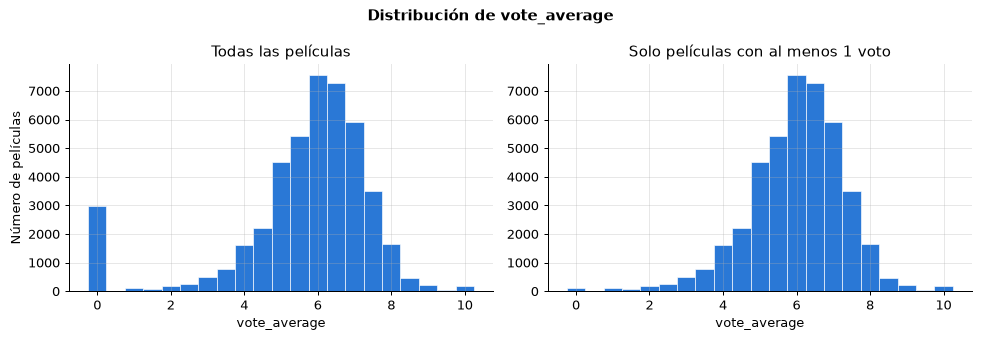

In [14]:
fig, ejes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=False)
bins = np.arange(-0.25, 10.26, 0.5)  # 0.5 de ancho, centrado en valores con un decimal

ejes[0].hist(df["vote_average"].dropna(), bins=bins, color=COLOR_PRINCIPAL, edgecolor="white", linewidth=0.5)
ejes[0].set_title("Todas las películas")
ejes[0].set_xlabel("vote_average")
ejes[0].set_ylabel("Número de películas")

con_votos = df.loc[df["vote_count"] > 0, "vote_average"]
ejes[1].hist(con_votos, bins=bins, color=COLOR_PRINCIPAL, edgecolor="white", linewidth=0.5)
ejes[1].set_title("Solo películas con al menos 1 voto")
ejes[1].set_xlabel("vote_average")

fig.suptitle("Distribución de vote_average", fontweight="bold")
fig.tight_layout()
plt.show()

La media de `vote_average` es 5,62 y la mediana 6,0, con desviación estándar de 1,92. El histograma de la izquierda muestra un pico aislado en 0: son 2.995 películas con `vote_average = 0`. Al quitar las películas sin votos (derecha), ese pico casi desaparece, lo que indica que la mayoría de esos ceros no son calificaciones reales sino ausencia de votos (se confirma en la sección 3.3). Sin ellas, la distribución se concentra entre 5 y 7.

### 3.3 Películas con pocos o 0 votos

`vote_average` es un promedio: si una película tiene 1 o 2 votos, su calificación depende de la opinión de una o dos personas y es muy ruidosa. Se cuantifica cuántas películas están en esa situación.

In [15]:
umbrales = [0, 1, 5, 10, 20, 50, 100]
tabla_votos = pd.DataFrame({
    "umbral": [f"vote_count <= {u}" for u in umbrales],
    "películas": [(df["vote_count"] <= u).sum() for u in umbrales],
    "porcentaje": [round((df["vote_count"] <= u).mean() * 100, 1) for u in umbrales],
})
tabla_votos

,umbral,películas,porcentaje
0,vote_count <= 0,2896,6.4
1,vote_count <= 1,6158,13.6
2,vote_count <= 5,16647,36.6
3,vote_count <= 10,23686,52.1
4,vote_count <= 20,30147,66.4
5,vote_count <= 50,36390,80.1
6,vote_count <= 100,39415,86.8


In [16]:
cero_votos = df["vote_count"] == 0
print(f"Películas con vote_count = 0: {cero_votos.sum():,}")
print(f"Películas con vote_average = 0: {(df['vote_average'] == 0).sum():,}")
print(f"  de ellas con vote_count = 0: {(cero_votos & (df['vote_average'] == 0)).sum():,}")
print(f"vote_average de las películas con 0 votos: {df.loc[cero_votos, 'vote_average'].unique()}")

Películas con vote_count = 0: 2,896
Películas con vote_average = 0: 2,995
  de ellas con vote_count = 0: 2,896
vote_average de las películas con 0 votos: [0.]


In [17]:
tramos = pd.cut(
    df["vote_count"],
    bins=[-1, 0, 5, 10, 20, 50, 100, np.inf],
    labels=["0", "1-5", "6-10", "11-20", "21-50", "51-100", ">100"],
)
resumen_tramos = df.groupby(tramos, observed=True)["vote_average"].agg(["count", "mean", "std"]).round(2)
resumen_tramos.index.name = "vote_count"
resumen_tramos

,count,mean,std
vote_count,,,
0,2896,0.00,0.00
1-5,13751,5.77,1.66
6-10,7039,5.88,1.18
11-20,6461,6.00,1.07
21-50,6243,6.13,1.00
51-100,3025,6.24,0.93
>100,6015,6.42,0.86


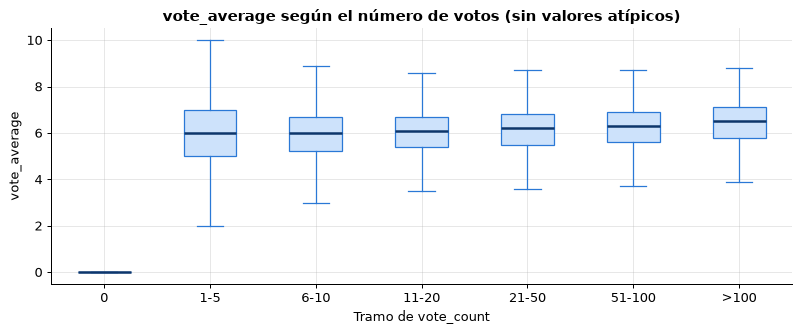

In [18]:
fig, ax = plt.subplots(figsize=(9, 3.8))
grupos = [df.loc[tramos == t, "vote_average"].dropna() for t in tramos.cat.categories]
ax.boxplot(
    grupos, tick_labels=list(tramos.cat.categories), showfliers=False,
    patch_artist=True,
    boxprops={"facecolor": "#cde2fb", "edgecolor": COLOR_PRINCIPAL},
    medianprops={"color": "#0d366b", "linewidth": 2},
    whiskerprops={"color": COLOR_PRINCIPAL}, capprops={"color": COLOR_PRINCIPAL},
)
ax.set_xlabel("Tramo de vote_count")
ax.set_ylabel("vote_average")
ax.set_title("vote_average según el número de votos (sin valores atípicos)", fontweight="bold")
fig.tight_layout()
plt.show()

Resultados:

- 2.896 películas (6,4 %) tienen 0 votos, y todas tienen `vote_average = 0`. Para ellas la variable objetivo no está definida: TMDB guarda 0 cuando nadie ha votado. Otras 99 películas tienen `vote_average = 0` con al menos 1 voto.
- El 52,1 % de las películas tiene 10 votos o menos, y el 36,6 % tiene 5 o menos.
- La dispersión de `vote_average` baja a medida que crece el número de votos: la desviación estándar pasa de 1,66 (1 a 5 votos) a 0,86 (más de 100 votos). Con pocos votos, la calificación depende de la opinión de muy pocas personas y es ruidosa.

Estos números sirven de base para decidir en la sección 4 si se filtran filas por número de votos. Filtrar filas es distinto de usar `vote_count` como predictora: `vote_count` nunca entra al modelo (fuga de información), pero sí puede usarse para decidir qué películas tienen una calificación confiable para entrenar y evaluar.

### 3.4 Ceros en `budget` (y en `revenue`)

TMDB guarda 0 cuando el presupuesto o la taquilla no se reportaron. Un 0 en estas columnas no significa "presupuesto cero" sino "dato desconocido".

In [19]:
for col in ["budget", "revenue"]:
    ceros = (df[col] == 0).sum()
    print(f"{col}: {ceros:,} ceros ({ceros / len(df):.1%}) | {(df[col] > 0).sum():,} con valor positivo")

presupuesto_pequeno = (df["budget"] > 0) & (df["budget"] < 1000)
print(f"\nbudget entre 1 y 999 dólares: {presupuesto_pequeno.sum()} películas")
df.loc[df["budget"] > 0, "budget"].describe().apply(lambda v: f"{v:,.0f}").to_frame("budget > 0")

budget: 36,550 ceros (80.5%) | 8,880 con valor positivo
revenue: 38,032 ceros (83.7%) | 7,398 con valor positivo

budget entre 1 y 999 dólares: 244 películas


,budget > 0
count,"8,880"
mean,"21,614,181"
std,"34,325,545"
min,1
25%,"2,000,000"
50%,"8,000,000"
75%,"25,000,000"
max,"380,000,000"


El 80,5 % de las películas (36.550) tiene `budget = 0`; solo 8.880 tienen presupuesto reportado. Si esos ceros se dejaran como números, el modelo interpretaría que la mayoría de películas costó 0 dólares. Por eso en la sección 4 se convierten a `NaN` antes de imputar. Además hay 244 películas con presupuesto entre 1 y 999 dólares, un valor poco creíble para un largometraje (posiblemente registrado en millones o mal capturado; no se verificó película por película). Se dejan anotadas, sin corregirlas a mano.

`revenue` tiene el mismo problema (83,7 % de ceros), pero no se usa como predictora por fuga de información (sección 4).

### 3.5 Duración (`runtime`)

In [20]:
print(f"runtime nulo: {df['runtime'].isna().sum()} ({df['runtime'].isna().mean():.2%})")
print(f"runtime = 0: {(df['runtime'] == 0).sum():,} ({(df['runtime'] == 0).mean():.2%})")
print(f"runtime > 300 minutos: {(df['runtime'] > 300).sum()}")
df["runtime"].describe().round(1).to_frame("runtime")

runtime nulo: 257 (0.57%)
runtime = 0: 1,558 (3.43%)
runtime > 300 minutos: 108


,runtime
count,45173.0
mean,94.1
std,38.4
min,0.0
25%,85.0
50%,95.0
75%,107.0
max,1256.0


`runtime` tiene 257 nulos (0,57 %) y, además, 1.558 películas (3,43 %) con duración 0, que tampoco es un valor real: igual que en `budget`, es un faltante codificado como 0. También hay 108 películas con más de 300 minutos (el máximo es 1.256), valores extremos que conviene tener en cuenta (un modelo basado en árboles es poco sensible a ellos). La mediana es 95 minutos.

### 3.6 Idioma original

In [21]:
frecuencia_idioma = df["original_language"].value_counts(normalize=True)
print(f"Idiomas distintos: {df['original_language'].nunique()}")
print(f"Idiomas con al menos 1 % de las películas: {(frecuencia_idioma >= 0.01).sum()}")
(frecuencia_idioma.head(12) * 100).round(2).to_frame("% de películas")

Idiomas distintos: 89
Idiomas con al menos 1 % de las películas: 8


,% de películas
original_language,
en,71.00
fr,5.36
it,3.37
ja,2.96
de,2.38
es,2.19
ru,1.82
hi,1.12
ko,0.98


Hay 89 idiomas originales, pero están muy desbalanceados: el inglés (`en`) concentra el 71,00 % de las películas y solo 8 idiomas superan el 1 %. Codificar los 89 idiomas crearía muchas columnas con casi ningún ejemplo, por eso en la sección 4 se agrupan los poco frecuentes en una categoría "otro".

### 3.7 Géneros

`genres` es un texto con formato de lista de diccionarios de Python, por ejemplo `"[{'id': 16, 'name': 'Animation'}, ...]"`. Para explorarlo se convierte con `ast.literal_eval`, que evalúa solo literales de Python (a diferencia de `eval`, no ejecuta código).

In [22]:
lista_generos = df["genres"].apply(lambda s: [g["name"] for g in ast.literal_eval(s)])
print(f"Películas sin ningún género: {(lista_generos.str.len() == 0).sum():,}")
print(f"Número de géneros por película: {lista_generos.str.len().value_counts().sort_index().to_dict()}")
primer_genero = lista_generos.str[0].value_counts()
primer_genero.to_frame("películas (primer género de la lista)")

Películas sin ningún género: 2,442
Número de géneros por película: {0: 2442, 1: 14552, 2: 14470, 3: 9577, 4: 3376, 5: 829, 6: 157, 7: 24, 8: 3}


,películas (primer género de la lista)
genres,
Drama,11953
Comedy,8816
Action,4486
Documentary,3413
Horror,2619
Crime,1684
Thriller,1663
Adventure,1509
Romance,1191


2.442 películas no tienen ningún género (lista vacía) y la mayoría tiene entre 1 y 3. Los géneros más frecuentes como primer elemento de la lista son Drama (11.953), Comedy (8.816) y Action (4.486). El "género principal" que se construye en la sección 4 parte de esta lista; las películas sin género necesitan una categoría propia.

### 3.8 Franquicias, fecha de estreno y otras columnas

In [23]:
print(f"Películas que pertenecen a una colección: {df['belongs_to_collection'].notna().sum():,} "
      f"({df['belongs_to_collection'].notna().mean():.1%})")

fecha = pd.to_datetime(df["release_date"], errors="coerce")
print(f"release_date no convertible a fecha: {fecha.isna().sum()} (incluye los {df['release_date'].isna().sum()} nulos)")
print(f"Rango de fechas: {fecha.min().date()} a {fecha.max().date()}")
print(f"Películas con fecha posterior a 2017: {(fecha.dt.year > 2017).sum()}")

for col in ["status", "adult", "video"]:
    print(f"\n{col}: {df[col].value_counts(dropna=False).to_dict()}")

Películas que pertenecen a una colección: 4,487 (9.9%)
release_date no convertible a fecha: 84 (incluye los 84 nulos)
Rango de fechas: 1874-12-09 a 2020-12-16
Películas con fecha posterior a 2017: 6

status: {'Released': 44985, 'Rumored': 229, 'Post Production': 98, nan: 81, 'In Production': 20, 'Planned': 15, 'Canceled': 2}

adult: {'False': 45421, 'True': 9}

video: {False: 45337, True: 93}


- Solo el 9,9 % de las películas (4.487) pertenece a una colección, lo que respalda usar `belongs_to_collection` como indicador binario `es_franquicia`.
- `release_date` tiene 84 nulos y el resto se convierte a fecha sin errores. Las fechas van de 1874 a 2020; hay 6 películas con fecha posterior a 2017. Según su descripción en Kaggle, el dataset reúne películas estrenadas hasta julio de 2017, así que esas fechas corresponden a estrenos anunciados en ese momento.
- `status`: 44.985 películas están estrenadas (`Released`) y 445 no (rumoreadas, en producción, planeadas, canceladas o sin dato).
- `adult` (9 en `True`) y `video` (93 en `True`) casi no varían, así que aportan poca información a un modelo.

### 3.9 Resumen del EDA

Hallazgos principales sobre el dataset limpio de 45.430 películas:

1. Se eliminaron 36 filas: 3 corruptas por parsing, 3 mitades incompletas de esas mismas líneas y 30 duplicados por `id`.
2. La variable objetivo `vote_average` no tiene nulos, pero 2.896 películas (6,4 %) tienen 0 votos y por eso una calificación de 0 que no es real. El 52,1 % tiene 10 votos o menos, y la calificación es más ruidosa cuanto menos votos hay.
3. `budget` tiene 80,5 % de ceros y `runtime` 3,43 % de ceros, que son faltantes codificados como 0. `runtime` tiene además 0,57 % de nulos reales, lo que cumple el requisito de la guía.
4. `original_language` está muy desbalanceado (71 % en inglés, 89 idiomas).
5. `genres` y `belongs_to_collection` requieren parseo o transformación antes de usarse.

Puntos que se deciden y justifican en la sección 4 (preparación de variables):

- Qué hacer con las películas con 0 o pocos votos (filtrado de filas por `vote_count`).
- Cómo tratar los ceros de `budget` y `runtime`.
- Cómo definir el género principal y cuántos idiomas conservar.
- Si se conservan las películas que no están en estado `Released`.